In [1]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy.stats import pearsonr

In [4]:
# Jasgulem ice core coordinates:
jasg_lat = 38.54063
jasg_lon = 72.269816

In [5]:
domain_2 = 'GRp'

In [10]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/daily/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'

In [8]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [9]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve la carotte Jasgulem

# distance sur grille
dist = np.sqrt((ds_lat - jasg_lat)**2 + (ds_lon - jasg_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le forage 2025")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le forage 2025
Indice Y : 26
Indice X : 47
Latitude : 38.54820251464844
Longitude : 72.30000305175781
Altitude : 5300.28369140625


In [12]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_daysum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [13]:
ds_SF

<xarray.DataArray 'SF' (time: 27394, Y: 62, X: 96)> Size: 652MB
array([[[3.74445226e-04, 2.14576969e-04, 6.15747122e-04, ...,
         9.30237293e-01, 6.70248866e-01, 4.91276324e-01],
        [1.05661296e-04, 7.68475438e-05, 2.11287959e-04, ...,
         9.68583107e-01, 6.82787478e-01, 5.73999166e-01],
        [7.95296219e-04, 6.30480761e-04, 1.15983246e-03, ...,
         9.55113709e-01, 6.76851690e-01, 6.45528078e-01],
        ...,
        [1.33852882e-03, 1.54444331e-03, 1.41463208e-03, ...,
         5.48581171e+00, 5.37602711e+00, 5.05049372e+00],
        [3.34798155e-04, 8.55999533e-04, 4.73424006e-04, ...,
         5.46231365e+00, 5.41271400e+00, 5.16628313e+00],
        [6.28568465e-04, 4.55760251e-04, 1.08436472e-03, ...,
         5.48615599e+00, 5.48335266e+00, 5.29903698e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.92853001e-02, 6.21224195e-02, 1.12359531e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.56769301e-02, 5.24942316e-02, 1.00929171e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.01129781e-02, 4.68667708e-02, 8.60349983e-02],
...
        [4.80213203e-07, 0.00000000e+00, 0.00000000e+00, ...,
         1.76276080e-03, 5.07454388e-03, 5.30155376e-03],
        [1.01281330e-05, 0.00000000e+00, 0.00000000e+00, ...,
         8.44430178e-03, 1.45093072e-02, 1.53873116e-02],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.06534751e-02, 2.27361452e-02, 1.97174959e-02]],

       [[1.50248525e-06, 2.65572453e-07, 3.63797881e-09, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [4.54747351e-09, 0.00000000e+00, 3.27418093e-07, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [2.65572453e-06, 1.47701940e-06, 4.18367563e-08, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [1.46756065e-04, 1.45839294e-04, 1.32917194e-04, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [7.43602868e-05, 1.14887371e-04, 1.69122359e-04, ...,
         0.00000000e+00, 0.00000000e+00, 3.86498868e-05],
        [9.05129127e-05, 1.61569915e-04, 2.04221578e-04, ...,
         0.00000000e+00, 0.00000000e+00, 1.14087015e-04]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 219kB 1950-01-01T12:00:00 ... 2024-12-31T1...
  * X        (X) float32 384B -329.0 -322.0 -315.0 -308.0 ... 322.0 329.0 336.0
  * Y        (Y) float32 248B -210.0 -203.0 -196.0 -189.0 ... 203.0 210.0 217.0
Attributes:
    long_name:     Snowfall
    units:         mmWE/day
    cell_methods:  TIME: sum
    history:       From ICE.p48.1950.01.01-31

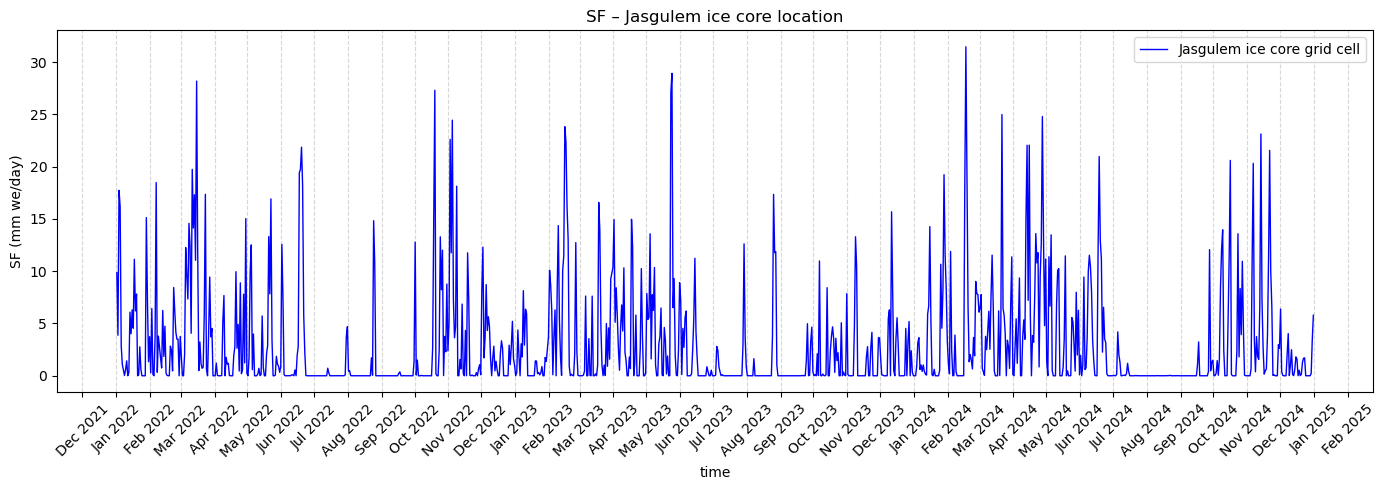

In [23]:
plt.figure(figsize=(14,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2022-01-01", "2024-12-31"))
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mm we/day)")

plt.tight_layout()
plt.show()

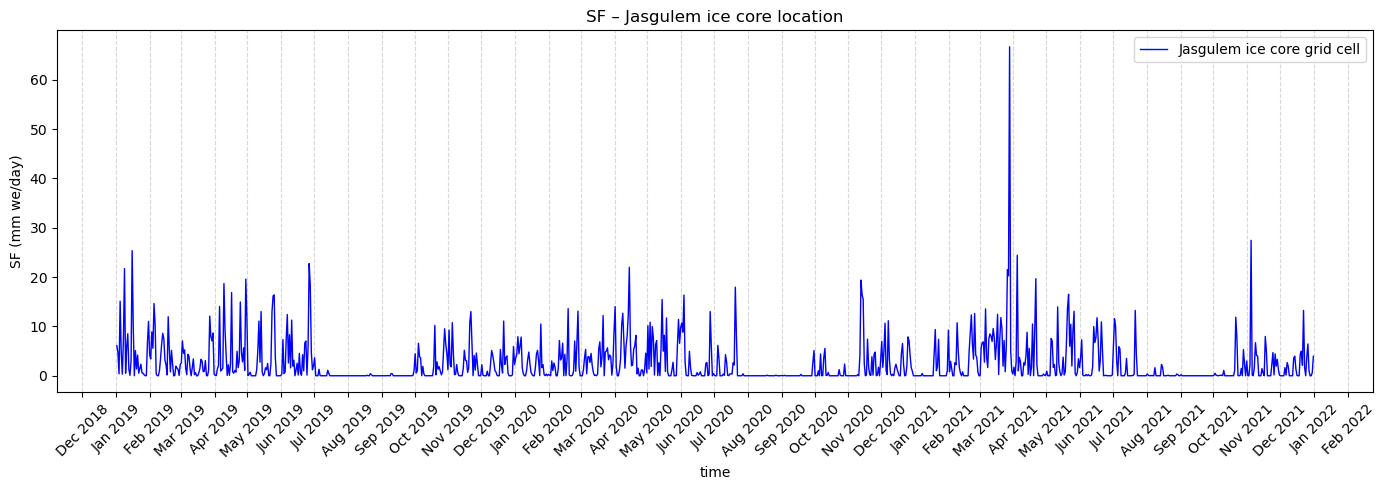

In [22]:
plt.figure(figsize=(14,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2019-01-01", "2021-12-31"))
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mm we/day)")

plt.tight_layout()
plt.show()

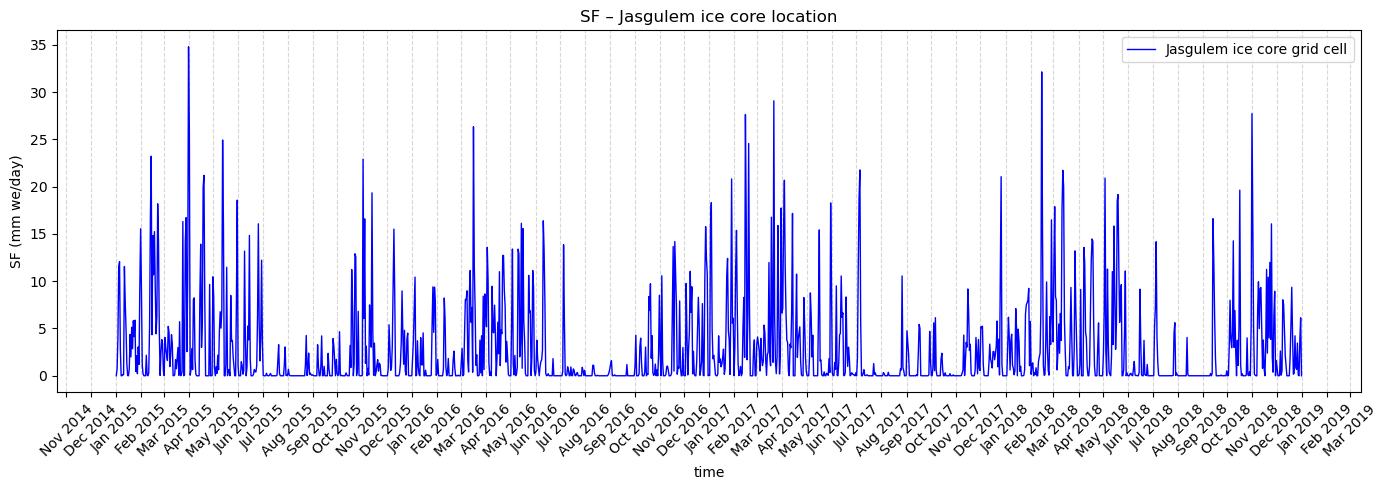

In [24]:
plt.figure(figsize=(14,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2015-01-01", "2018-12-31"))
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mm we/day)")

plt.tight_layout()
plt.show()

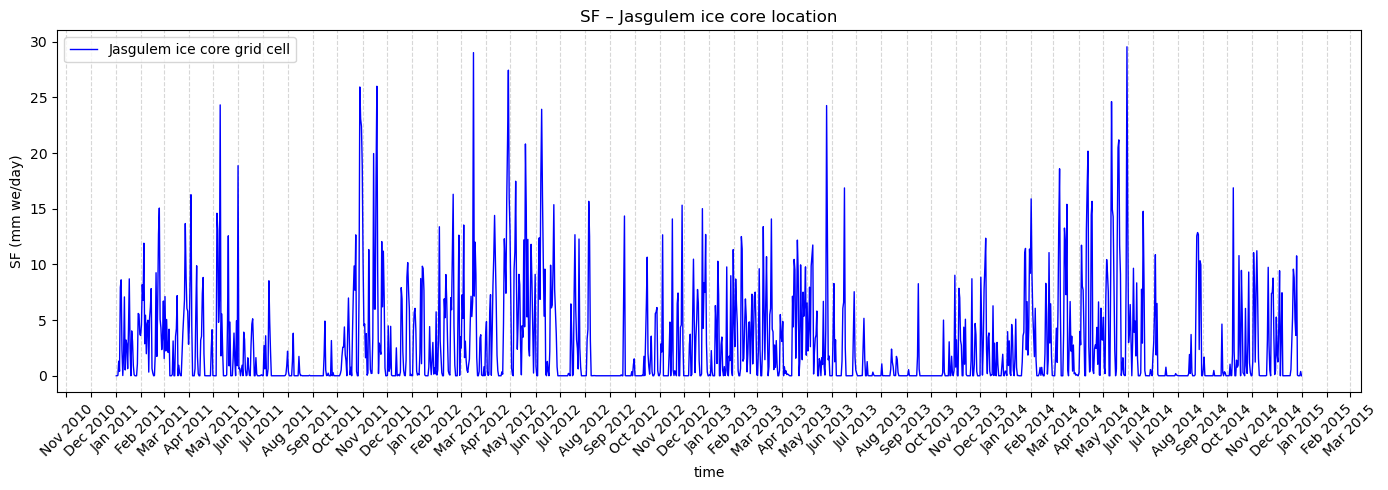

In [25]:
plt.figure(figsize=(14,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2011-01-01", "2014-12-31"))
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mm we/day)")

plt.tight_layout()
plt.show()

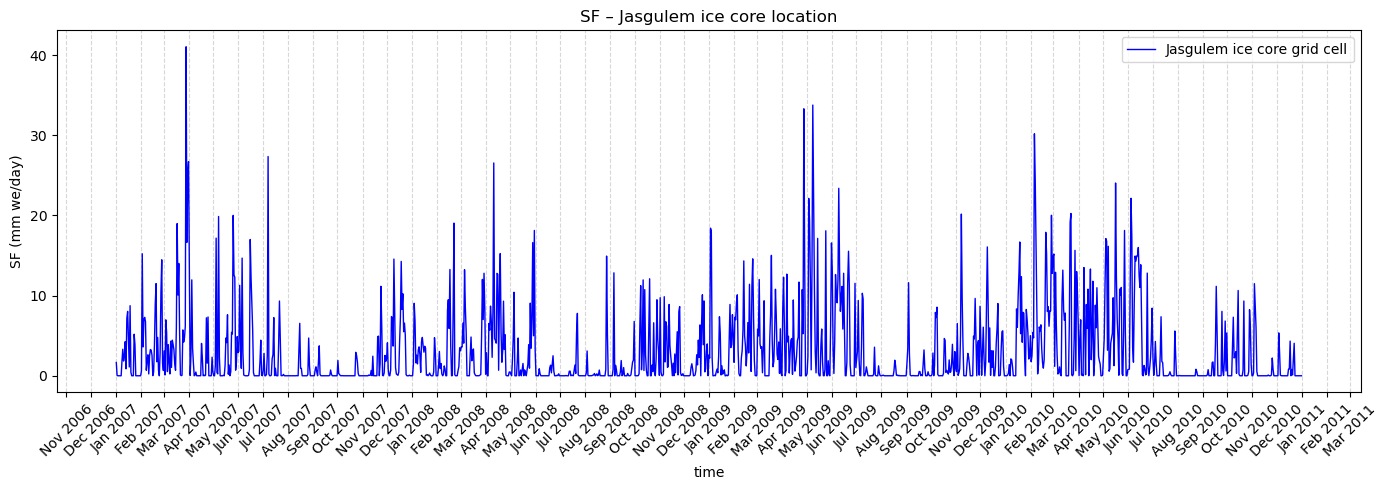

In [26]:
plt.figure(figsize=(14,5))

ds_SF_jasg = ds_SF.isel(Y=iY, X=iX).sel(time=slice("2007-01-01", "2010-12-31"))
ds_SF_jasg.plot(label="Jasgulem ice core grid cell", linewidth=1, color="blue")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.5)

plt.legend(ncol=3)
plt.title("SF – Jasgulem ice core location")
plt.ylabel("SF (mm we/day)")

plt.tight_layout()
plt.show()